In [ ]:
# [셀 1] PyTorch 설치 (Colab 또는 로컬 Jupyter 환경용)
# !pip install torch --quiet  # 이미 설치되어 있다면 주석 처리하거나 생략 가능

In [ ]:
# [셀 2] 라이브러리 임포트 및 데이터셋 정의
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 구구단 데이터셋 (정수 그대로 사용)
class GuguDataset(Dataset):
    def __init__(self):
        self.data = []

        self.x_scale = 9.0
        self.y_scale = 81.0

        for a in range(2, 10):
            for b in range(1, 10):
                c = a * b
                # 입력: a, b (정수), 출력: c (정수)
                # x = torch.tensor([a, b], dtype=torch.float32)
                # y = torch.tensor([c], dtype=torch.float32)
                x = torch.tensor(
                    [a, b], dtype=torch.float32
                ) / self.x_scale
                y = torch.tensor(
                    [c], dtype=torch.float32
                ) / self.y_scale
                self.data.append((x, y))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

    def normalize_x(self, x):
        return x / self.x_scale

    def denormalize_y(self, y):
        return y * self.y_scale

In [ ]:
# [셀 3] 모델 정의 (MLP)
class GuguNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
# [셀 4] 학습 설정 및 학습 루프
dataset = GuguDataset()
loader = DataLoader(dataset, batch_size=16, shuffle=True)
model = GuguNet()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 1000
loss_history = []

for epoch in range(epochs):
    total_loss = 0.0
    for x_batch, y_batch in loader:
        optimizer.zero_grad()
        y_pred = model(x_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x_batch.size(0)
    avg_loss = total_loss / len(dataset)
    loss_history.append(avg_loss)
    if (epoch + 1) % 100 == 0:
      print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.9f}")

Epoch 100/1000, Loss: 0.000064077
Epoch 200/1000, Loss: 0.000013829
Epoch 300/1000, Loss: 0.000024505
Epoch 400/1000, Loss: 0.000032356
Epoch 500/1000, Loss: 0.000005062
Epoch 600/1000, Loss: 0.000003984
Epoch 700/1000, Loss: 0.000009180
Epoch 800/1000, Loss: 0.000011277
Epoch 900/1000, Loss: 0.000008920
Epoch 1000/1000, Loss: 0.000005514


/tmp/ipykernel_932/1684033882.py:8: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_932/1684033882.py:8: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_932/1684033882.py:8: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_932/1684033882.py:8: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_932/1684033882.py:8: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_932/1684033882.py:8: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_932/1684033882.py:8: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/i

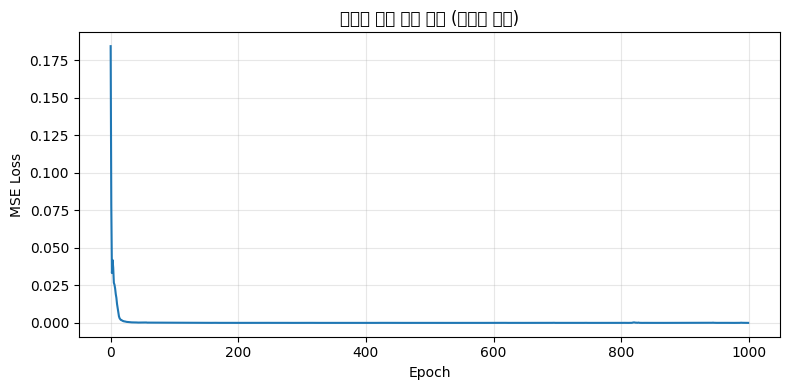

In [ ]:
# [셀 5] 학습 손실 시각화
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("구구단 학습 손실 곡선 (정규화 없음)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# [셀 6] 평가: 전체 구구단에 대해 예측 오차 확인
model.eval()
errors = []
with torch.no_grad():
    for a in range(2, 10):
        for b in range(1, 10):
            x = torch.tensor([[a, b]], dtype=torch.float32)
            x = dataset.normalize_x(x) # 새로 추가
            y_true = a * b
            # y_pred = round(model(x).item()) # 정수 변환을 위한 반올림 처리
            y_pred = model(x).item()
            y_pred = dataset.denormalize_y(y_pred)
            y_pred = round(y_pred)
            err = abs(y_pred - y_true)
            errors.append((a, b, y_true, y_pred, err))

# 오차 통계
err_vals = [e[4] for e in errors]
print(f"\n평균 절대 오차: {np.mean(err_vals):.3f}")
print(f"최대 오차: {np.max(err_vals)}")
print(f"정확히 맞춘 개수: {sum(1 for e in err_vals if e == 0)}/{len(err_vals)}")

# 전체 결과 테이블 출력
print("\n전체 예측 결과 (a, b, 실제, 예측, 오차):")
for e in errors:
    print(e)


평균 절대 오차: 0.014
최대 오차: 1
정확히 맞춘 개수: 71/72

전체 예측 결과 (a, b, 실제, 예측, 오차):
(2, 1, 2, 2, 0)
(2, 2, 4, 4, 0)
(2, 3, 6, 6, 0)
(2, 4, 8, 8, 0)
(2, 5, 10, 10, 0)
(2, 6, 12, 12, 0)
(2, 7, 14, 14, 0)
(2, 8, 16, 16, 0)
(2, 9, 18, 18, 0)
(3, 1, 3, 3, 0)
(3, 2, 6, 6, 0)
(3, 3, 9, 9, 0)
(3, 4, 12, 12, 0)
(3, 5, 15, 15, 0)
(3, 6, 18, 18, 0)
(3, 7, 21, 21, 0)
(3, 8, 24, 24, 0)
(3, 9, 27, 27, 0)
(4, 1, 4, 4, 0)
(4, 2, 8, 8, 0)
(4, 3, 12, 12, 0)
(4, 4, 16, 16, 0)
(4, 5, 20, 20, 0)
(4, 6, 24, 24, 0)
(4, 7, 28, 28, 0)
(4, 8, 32, 32, 0)
(4, 9, 36, 36, 0)
(5, 1, 5, 5, 0)
(5, 2, 10, 10, 0)
(5, 3, 15, 15, 0)
(5, 4, 20, 20, 0)
(5, 5, 25, 25, 0)
(5, 6, 30, 30, 0)
(5, 7, 35, 35, 0)
(5, 8, 40, 40, 0)
(5, 9, 45, 45, 0)
(6, 1, 6, 6, 0)
(6, 2, 12, 12, 0)
(6, 3, 18, 18, 0)
(6, 4, 24, 24, 0)
(6, 5, 30, 30, 0)
(6, 6, 36, 36, 0)
(6, 7, 42, 42, 0)
(6, 8, 48, 48, 0)
(6, 9, 54, 54, 0)
(7, 1, 7, 7, 0)
(7, 2, 14, 14, 0)
(7, 3, 21, 21, 0)
(7, 4, 28, 28, 0)
(7, 5, 35, 35, 0)
(7, 6, 42, 42, 0)
(7, 7, 49, 49, 0)
(7, 8, 56, 56, 

/tmp/ipykernel_932/1828924868.py:14: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_932/1828924868.py:14: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_932/1828924868.py:14: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_932/1828924868.py:14: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_932/1828924868.py:14: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_932/1828924868.py:14: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_932/1828924868.py:14: UserWarning: Glyph 55176 (\N{HANGUL SYLLABLE HI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp

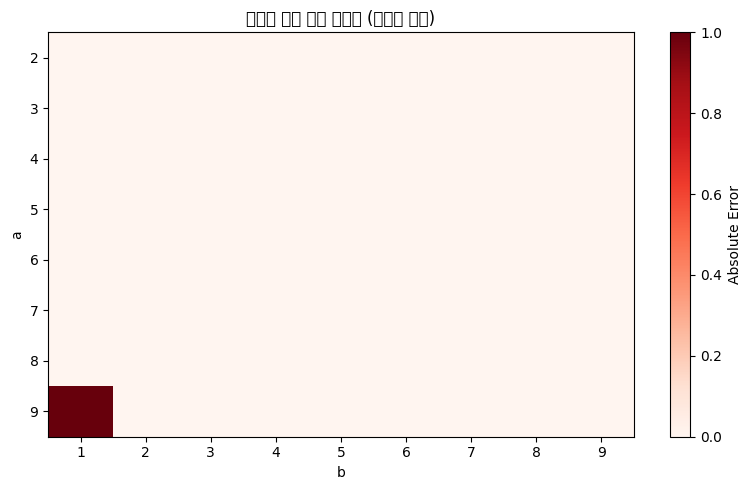

In [ ]:
# [셀 7] 오차 히트맵 시각화
error_matrix = np.zeros((8, 9))  # a:2~9 (8개), b:1~9 (9개)
for a, b, _, _, err in errors:
    error_matrix[a-2, b-1] = err

plt.figure(figsize=(8, 5))
plt.imshow(error_matrix, cmap='Reds', aspect='auto')
plt.colorbar(label='Absolute Error')
plt.xticks(range(9), range(1, 10))
plt.yticks(range(8), range(2, 10))
plt.xlabel('b')
plt.ylabel('a')
plt.title('구구단 예측 오차 히트맵 (정규화 없음)')
plt.tight_layout()
plt.show()